# Load data variables

In [456]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import matplotlib.dates as mdates

from plotting import filter_time_range
from plotting import filter_n_frames

'''
# Spin State 1
start_datetime_str = "2025-11-06T11:00:00"
end_datetime_str = "2025-11-11T00:00:00"

# Spin State 2 (OSM2)
start_datetime_str = "2025-12-02T13:00:00"
end_datetime_str = "2025-12-06T10:00:00"

# Spin State 3 (LOI)
s3 = np.datetime64("2026-01-05T12:00:00")
e3 = np.datetime64("2026-01-08T12:00:00") # modified

# Earth Only
s4 = np.datetime64("2026-02-07T00:00:00")
e4 = np.datetime64("2026-03-02T00:00:00")
'''


# ------------------------ PARAMETERS ------------------------
start_datetime_str = "2026-02-07T00:00:00"
end_datetime_str = "2026-03-03T12:00:00"
filter_neg = True   # Set to True to filter out negative FOV values, False to keep all values
beta_max = 360     # Set to a value less than 360 to filter out data points with beta angles above the specified maximum, or set to 360 to keep all values
# ------------------------ PARAMETERS ------------------------



ds = xr.open_dataset("products/WFI_FOV_AVG.nc")
wfi_fov_mean_top = ds['fov_mean_top']
wfi_fov_mean_bottom = ds['fov_mean_bottom']
wfi_fov_mean_top_uncorrected = ds['fov_mean_top_uncorrected']
wfi_fov_mean_bottom_uncorrected = ds['fov_mean_bottom_uncorrected']
wfi_time = ds['time']
wfi_roll_angles = ds['roll_angles']
wfi_beta_angles = ds['beta_angles']
wfi_n_frames = ds['n_frames']
ds.close()

ds = xr.open_dataset("products/NFI_FOV_AVG.nc")
nfi_fov_mean_top = ds['fov_mean_top']
nfi_fov_mean_bottom = ds['fov_mean_bottom']
nfi_fov_mean_top_uncorrected = ds['fov_mean_top_uncorrected']
nfi_fov_mean_bottom_uncorrected = ds['fov_mean_bottom_uncorrected']
nfi_time = ds['time']
nfi_roll_angles = ds['roll_angles']
nfi_beta_angles = ds['beta_angles']
nfi_n_frames = ds['n_frames']
ds.close()


start_dt = np.datetime64(start_datetime_str)
end_dt = np.datetime64(end_datetime_str)

'''
n_frames_min = 7000

# Filter the number of frames
wfi_fov_mean_top = filter_n_frames(wfi_fov_mean_top, wfi_n_frames, n_frames_min)
wfi_fov_mean_bottom = filter_n_frames(wfi_fov_mean_bottom, wfi_n_frames, n_frames_min)
wfi_time = filter_n_frames(wfi_time, wfi_n_frames, n_frames_min)
wfi_roll_angles = filter_n_frames(wfi_roll_angles, wfi_n_frames, n_frames_min)
wfi_beta_angles = filter_n_frames(wfi_beta_angles, wfi_n_frames, n_frames_min)
nfi_fov_mean_top = filter_n_frames(nfi_fov_mean_top, nfi_n_frames, n_frames_min)
nfi_fov_mean_bottom = filter_n_frames(nfi_fov_mean_bottom, nfi_n_frames, n_frames_min)
nfi_time = filter_n_frames(nfi_time, nfi_n_frames, n_frames_min)
nfi_roll_angles = filter_n_frames(nfi_roll_angles, nfi_n_frames, n_frames_min)
nfi_beta_angles = filter_n_frames(nfi_beta_angles, nfi_n_frames, n_frames_min)

'''

# Filter the time range
wfi_fov_mean_top    = filter_time_range(wfi_fov_mean_top,    wfi_time, start_dt, end_dt)
wfi_fov_mean_top_uncorrected    = filter_time_range(wfi_fov_mean_top_uncorrected,    wfi_time, start_dt, end_dt)
wfi_fov_mean_bottom = filter_time_range(wfi_fov_mean_bottom, wfi_time, start_dt, end_dt)
wfi_fov_mean_bottom_uncorrected = filter_time_range(wfi_fov_mean_bottom_uncorrected, wfi_time, start_dt, end_dt)
wfi_roll_angles     = filter_time_range(wfi_roll_angles,     wfi_time, start_dt, end_dt)
wfi_beta_angles     = filter_time_range(wfi_beta_angles,     wfi_time, start_dt, end_dt)
wfi_time            = filter_time_range(wfi_time,            wfi_time, start_dt, end_dt)  # filter last

nfi_fov_mean_top    = filter_time_range(nfi_fov_mean_top,    nfi_time, start_dt, end_dt)
nfi_fov_mean_top_uncorrected    = filter_time_range(nfi_fov_mean_top_uncorrected,    nfi_time, start_dt, end_dt)
nfi_fov_mean_bottom = filter_time_range(nfi_fov_mean_bottom, nfi_time, start_dt, end_dt)
nfi_fov_mean_bottom_uncorrected = filter_time_range(nfi_fov_mean_bottom_uncorrected, nfi_time, start_dt, end_dt)    
nfi_roll_angles     = filter_time_range(nfi_roll_angles,     nfi_time, start_dt, end_dt)
nfi_beta_angles     = filter_time_range(nfi_beta_angles,     nfi_time, start_dt, end_dt)
nfi_time            = filter_time_range(nfi_time,            nfi_time, start_dt, end_dt)  # filter last

if filter_neg == True:
    # Filter out values where corrected FOV Avgs are negative across all variables
    valid_indices_wfi = (wfi_fov_mean_top > 0) | (wfi_fov_mean_bottom > 0) 
    valid_indices_nfi = (nfi_fov_mean_top > 0) | (nfi_fov_mean_bottom > 0)
    wfi_fov_mean_top = wfi_fov_mean_top[valid_indices_wfi]
    wfi_fov_mean_bottom = wfi_fov_mean_bottom[valid_indices_wfi]
    nfi_fov_mean_top = nfi_fov_mean_top[valid_indices_nfi]
    nfi_fov_mean_bottom = nfi_fov_mean_bottom[valid_indices_nfi ]
    wfi_fov_mean_top_uncorrected = wfi_fov_mean_top_uncorrected[valid_indices_wfi]
    wfi_fov_mean_bottom_uncorrected = wfi_fov_mean_bottom_uncorrected[valid_indices_wfi]
    nfi_fov_mean_top_uncorrected = nfi_fov_mean_top_uncorrected[valid_indices_nfi]
    nfi_fov_mean_bottom_uncorrected = nfi_fov_mean_bottom_uncorrected[valid_indices_nfi]
    wfi_time = wfi_time[valid_indices_wfi]
    nfi_time = nfi_time[valid_indices_nfi]
    wfi_roll_angles = wfi_roll_angles[valid_indices_wfi]
    wfi_beta_angles = wfi_beta_angles[valid_indices_wfi]
    nfi_roll_angles = nfi_roll_angles[valid_indices_nfi]
    nfi_beta_angles = nfi_beta_angles[valid_indices_nfi]

if beta_max < 360:
    # Filter out values where beta angles are above the specified maximum across all variables
    valid_indices_wfi = (wfi_beta_angles <= beta_max)
    valid_indices_nfi = (nfi_beta_angles <= beta_max)
    wfi_fov_mean_top = wfi_fov_mean_top[valid_indices_wfi]
    wfi_fov_mean_bottom = wfi_fov_mean_bottom[valid_indices_wfi]
    nfi_fov_mean_top = nfi_fov_mean_top[valid_indices_nfi]
    nfi_fov_mean_bottom = nfi_fov_mean_bottom[valid_indices_nfi ]
    wfi_fov_mean_top_uncorrected = wfi_fov_mean_top_uncorrected[valid_indices_wfi]
    wfi_fov_mean_bottom_uncorrected = wfi_fov_mean_bottom_uncorrected[valid_indices_wfi]
    nfi_fov_mean_top_uncorrected = nfi_fov_mean_top_uncorrected[valid_indices_nfi]
    nfi_fov_mean_bottom_uncorrected = nfi_fov_mean_bottom_uncorrected[valid_indices_nfi]
    wfi_time = wfi_time[valid_indices_wfi]
    nfi_time = nfi_time[valid_indices_nfi]
    wfi_roll_angles = wfi_roll_angles[valid_indices_wfi]
    wfi_beta_angles = wfi_beta_angles[valid_indices_wfi]
    nfi_roll_angles = nfi_roll_angles[valid_indices_nfi]
    nfi_beta_angles = nfi_beta_angles[valid_indices_nfi]



# Calculate the average of the top and bottom FOV Avgs
wfi_avg_fov_mean = np.mean([wfi_fov_mean_top, wfi_fov_mean_bottom], axis=0)
nfi_avg_fov_mean = np.mean([nfi_fov_mean_top, nfi_fov_mean_bottom], axis=0)

# Calculate the average of the uncorrected top and bottom FOV Avgs
wfi_avg_fov_mean_uncorrected = np.mean([wfi_fov_mean_top_uncorrected, wfi_fov_mean_bottom_uncorrected], axis=0)
nfi_avg_fov_mean_uncorrected = np.mean([nfi_fov_mean_top_uncorrected, nfi_fov_mean_bottom_uncorrected], axis=0)


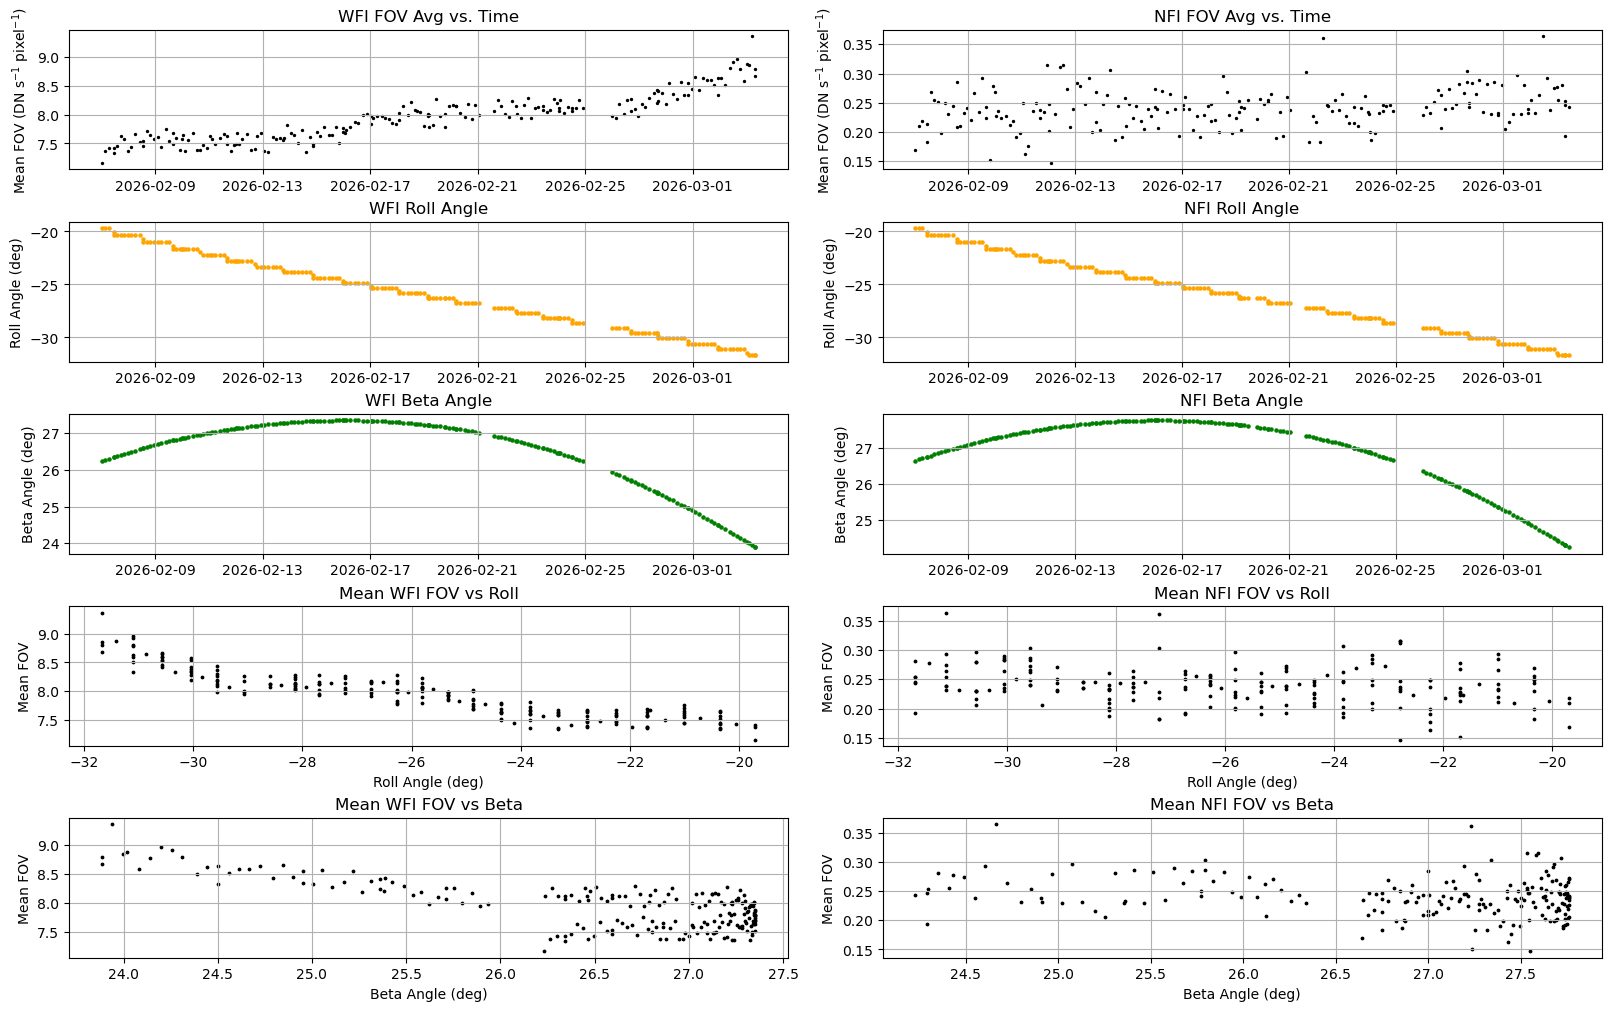

In [457]:
# Create the figure and a 5x2 axes array
fig, axs = plt.subplots(5, 2, figsize=(16, 10), constrained_layout=True)

# --- ROW 0: FOV Avg vs Time ---
# WFI (Left)
axs[0, 0].scatter(wfi_time, wfi_avg_fov_mean, label='Avg Mean FOV', color='black', alpha=1, s=2)
axs[0, 0].set_title('WFI FOV Avg vs. Time')
axs[0, 0].set_ylabel('Mean FOV (DN s$^{-1}$ pixel$^{-1}$)')
axs[0, 0].grid(True)
#axs[0, 0].set_ylim(2, 20)

# NFI (Right)
axs[0, 1].scatter(nfi_time, nfi_avg_fov_mean, label='Avg Mean FOV', color='black', alpha=1, s=2)
axs[0, 1].set_title('NFI FOV Avg vs. Time')
axs[0, 1].set_ylabel('Mean FOV (DN s$^{-1}$ pixel$^{-1}$)')
axs[0, 1].grid(True)


# --- ROW 1: Roll Angle ---
# WFI (Left)
axs[1, 0].scatter(wfi_time, wfi_roll_angles, s=5, color='orange')
axs[1, 0].set_title('WFI Roll Angle')
axs[1, 0].set_ylabel('Roll Angle (deg)')
axs[1, 0].grid(True)

# NFI (Right)
axs[1, 1].scatter(nfi_time, nfi_roll_angles, s=5, color='orange')
axs[1, 1].set_title('NFI Roll Angle')
axs[1, 1].set_ylabel('Roll Angle (deg)')
axs[1, 1].grid(True)


# --- ROW 2: Beta Angle ---
# WFI (Left)
axs[2, 0].scatter(wfi_time, wfi_beta_angles, s=5, color='green')
axs[2, 0].set_title('WFI Beta Angle')
axs[2, 0].set_ylabel('Beta Angle (deg)')
axs[2, 0].grid(True)

# NFI (Right)
axs[2, 1].scatter(nfi_time, nfi_beta_angles, s=5, color='green')
axs[2, 1].set_title('NFI Beta Angle')
axs[2, 1].set_ylabel('Beta Angle (deg)')
axs[2, 1].grid(True)


# --- ROW 3: FOV vs Roll (Comparative) ---
# WFI: FOV vs Roll (Left)
axs[3, 0].scatter(wfi_roll_angles, wfi_avg_fov_mean, s=3, color='black')
axs[3, 0].set_title('Mean WFI FOV vs Roll')
axs[3, 0].set_xlabel('Roll Angle (deg)')
axs[3, 0].set_ylabel('Mean FOV')
axs[3, 0].grid(True)

# NFI: FOV vs Roll (Right)
axs[3, 1].scatter(nfi_roll_angles, nfi_avg_fov_mean, s=3, color='black')
axs[3, 1].set_title('Mean NFI FOV vs Roll')
axs[3, 1].set_xlabel('Roll Angle (deg)')
axs[3, 1].set_ylabel('Mean FOV')
axs[3, 1].grid(True)

# --- ROW 4: FOV vs Beta (Comparative) ---
# WFI: FOV vs Beta (Left)
axs[4, 0].scatter(wfi_beta_angles, wfi_avg_fov_mean, s=3, color='black')
axs[4, 0].set_title('Mean WFI FOV vs Beta')
axs[4, 0].set_xlabel('Beta Angle (deg)')
axs[4, 0].set_ylabel('Mean FOV')
axs[4, 0].grid(True)

# NFI: FOV vs Beta (Right)
axs[4, 1].scatter(nfi_beta_angles, nfi_avg_fov_mean , s=3, color='black')
axs[4, 1].set_title('Mean NFI FOV vs Beta')
axs[4, 1].set_xlabel('Beta Angle (deg)')
axs[4, 1].set_ylabel('Mean FOV')
axs[4, 1].grid(True)


plt.show()


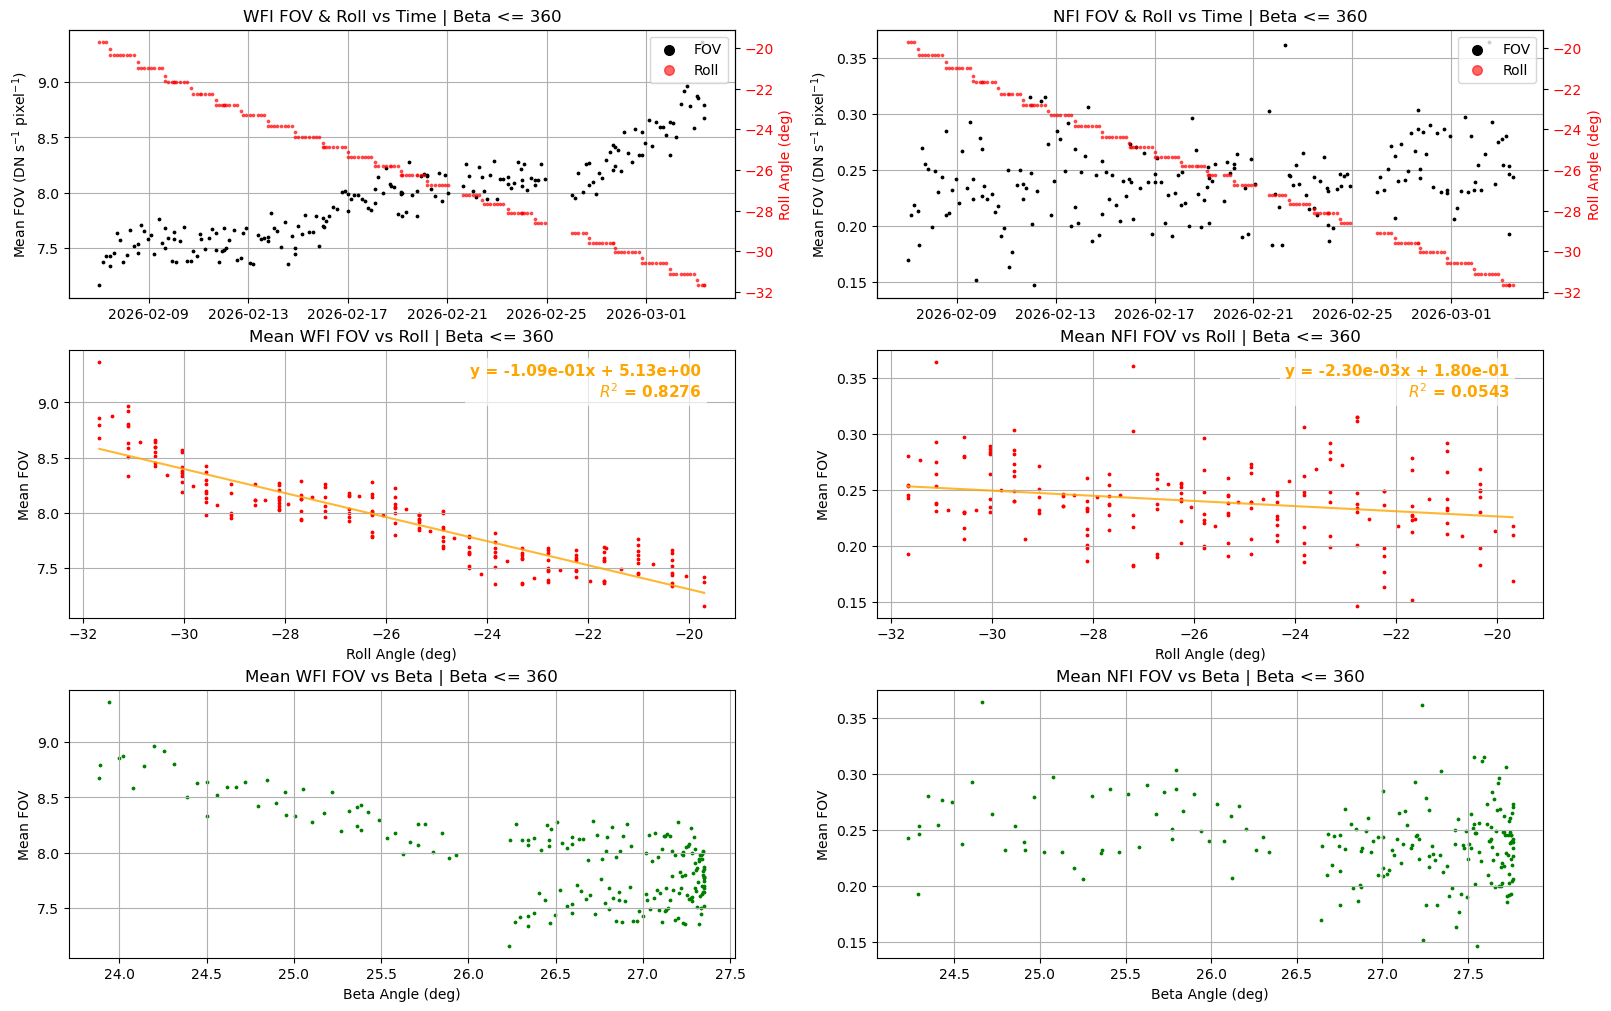

In [458]:
# Create the figure - 3 rows total (0, 1, 2)
fig, axs = plt.subplots(3, 2, figsize=(16, 10), constrained_layout=True)

# Function for ROW 0: Combined FOV and Roll vs Time
def plot_combined_time_series(ax, time, fov, roll, title):
    ax.grid(True)
    p1 = ax.scatter(time, fov, label='FOV', s=3, color='black', zorder=3)
    ax.set_ylabel('Mean FOV (DN s$^{-1}$ pixel$^{-1}$)')
    ax.set_title(title)

    ax_roll = ax.twinx()
    p2 = ax_roll.scatter(time, roll, label='Roll', s=3, color='red', alpha=0.6)
    ax_roll.set_ylabel('Roll Angle (deg)', color='red')
    ax_roll.tick_params(axis='y', labelcolor='red')

    # Legend in upper right
    ax.legend(handles=[p1, p2], labels=['FOV', 'Roll'], loc='upper right', markerscale=4)

# --- ROW 0: Combined Time Series ---
plot_combined_time_series(axs[0, 0], wfi_time, wfi_avg_fov_mean, wfi_roll_angles, f'WFI FOV & Roll vs Time | Beta <= {beta_max}')
plot_combined_time_series(axs[0, 1], nfi_time, nfi_avg_fov_mean, nfi_roll_angles, f'NFI FOV & Roll vs Time | Beta <= {beta_max}')

# --- ROW 1: FOV vs Roll (Comparative with R^2 and Equations) ---
for i, (angles, fov, title) in enumerate([(wfi_roll_angles, wfi_avg_fov_mean, 'WFI'), 
                                           (nfi_roll_angles, nfi_avg_fov_mean, 'NFI')]):
    ax = axs[1, i]
    ax.scatter(angles, fov, s=3, color='red')
    ax.set_title(f'Mean {title} FOV vs Roll | Beta <= {beta_max}')
    ax.set_xlabel('Roll Angle (deg)')
    ax.set_ylabel('Mean FOV')
    ax.grid(True)

    # Trendline & R^2
    m, b = np.polyfit(angles, fov, 1)
    r_sq = np.corrcoef(angles, fov)[0, 1]**2
    ax.plot(angles, m * angles + b, color='orange', alpha=0.8, label='Fit')
    
    # Equation text in UPPER RIGHT
    eq_text = f'y = {m:.2e}x + {b:.2e}\n$R^2$ = {r_sq:.4f}'
    ax.text(0.95, 0.95, eq_text, transform=ax.transAxes, ha='right', va='top', 
            fontsize=11, color='orange', fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- ROW 2: FOV vs Beta (Comparative - No Trendlines) ---
# Ensure these use axs[2, 0] and axs[2, 1]
for i, (angles, fov, title) in enumerate([(wfi_beta_angles, wfi_avg_fov_mean, 'WFI'), 
                                           (nfi_beta_angles, nfi_avg_fov_mean, 'NFI')]):
    ax = axs[2, i]
    ax.scatter(angles, fov, s=3, color='green')
    ax.set_title(f'Mean {title} FOV vs Beta | Beta <= {beta_max}')
    ax.set_xlabel('Beta Angle (deg)')
    ax.set_ylabel('Mean FOV')
    ax.grid(True)

plt.show()


"\nm, b = np.polyfit(mdates.date2num(nfi_time), nfi_avg_fov_mean, 1)\naxs[1].plot(nfi_time, m * mdates.date2num(nfi_time) + b, label='FOV vs Roll Fit', color='orange', alpha=0.8)\nequation_text = f'y = {m:e}x + {b:e}'\naxs[1].text(0.05, 0.05, equation_text, transform=axs[1].transAxes, ha='left', va='bottom', fontsize=12, color='orange', fontweight='bold')\n"

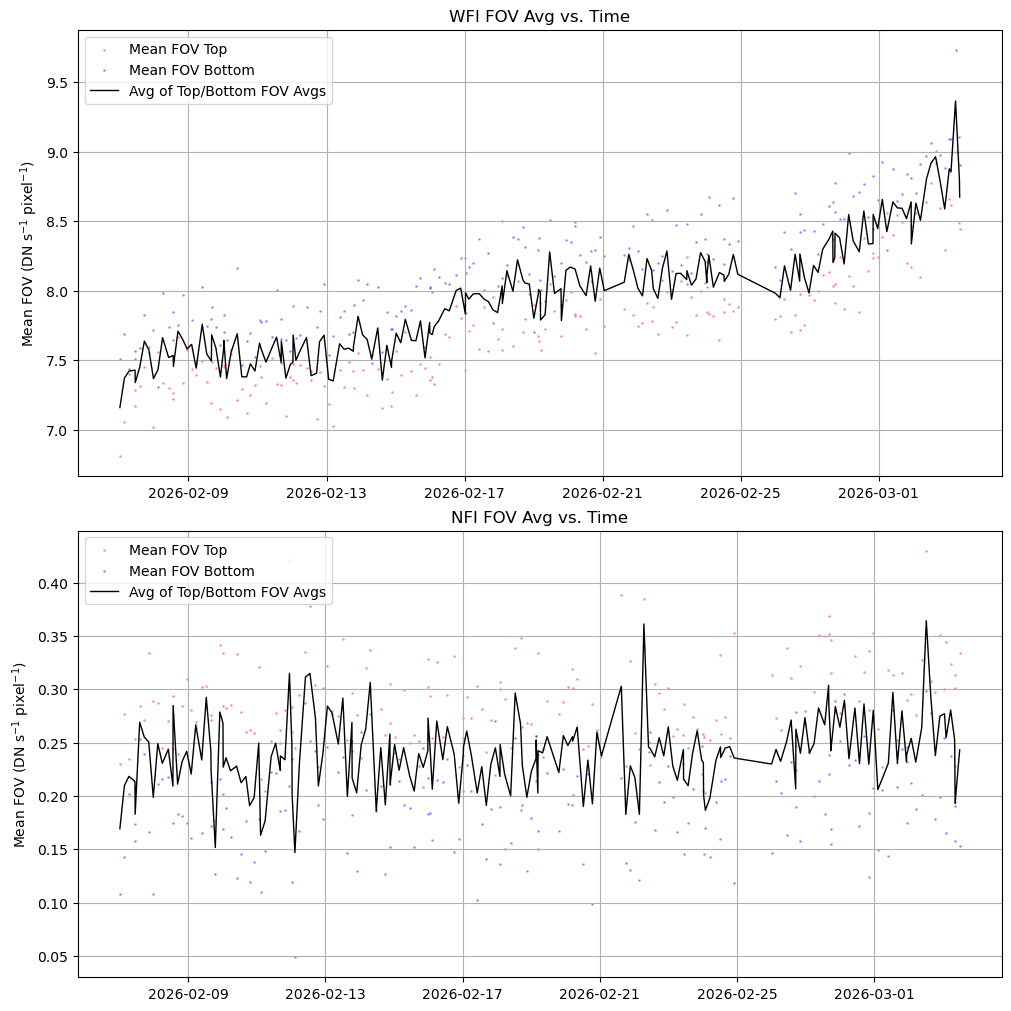

In [459]:
# Create the figure and axes array
fig, axs = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True)

# --- Subplot 0: Mean FOV with Angles on Twin Axis ---
axs[0].scatter(wfi_time, wfi_fov_mean_top, s=1, label='Mean FOV Top', color='red', alpha=0.3)
axs[0].scatter(wfi_time, wfi_fov_mean_bottom, s=1, label='Mean FOV Bottom', color='blue', alpha=0.3)
axs[0].plot(wfi_time, wfi_avg_fov_mean, label='Avg of Top/Bottom FOV Avgs', color='black', alpha=1, linewidth=1)
axs[0].set_title('WFI FOV Avg vs. Time')
axs[0].set_ylabel('Mean FOV (DN s$^{-1}$ pixel$^{-1}$)')
#axs[0].set_yscale('log')
axs[0].legend(loc='upper left')
axs[0].grid(True)
'''
m, b = np.polyfit(mdates.date2num(wfi_time), wfi_avg_fov_mean, 1)
axs[0].plot(wfi_time, m * mdates.date2num(wfi_time) + b, label='FOV vs Roll Fit', color='orange', alpha=0.8)
equation_text = f'y = {m:e}x + {b:e}'
axs[0].text(0.05, 0.05, equation_text, transform=axs[0].transAxes, ha='left', va='bottom', fontsize=12, color='orange', fontweight='bold')
'''
# --- Subplot 1: Mean NFI FOV with Angles on Twin Axis ---
axs[1].scatter(nfi_time, nfi_fov_mean_top, s=1, label='Mean FOV Top', color='red', alpha=0.3)
axs[1].scatter(nfi_time, nfi_fov_mean_bottom, s=1, label='Mean FOV Bottom', color='blue', alpha=0.3)
axs[1].plot(nfi_time, nfi_avg_fov_mean, label='Avg of Top/Bottom FOV Avgs', color='black', alpha=1, linewidth=1)
axs[1].set_title('NFI FOV Avg vs. Time')
axs[1].set_ylabel('Mean FOV (DN s$^{-1}$ pixel$^{-1}$)')
#axs[1].set_yscale('log')
axs[1].legend(loc='upper left')
axs[1].grid(True)
'''
m, b = np.polyfit(mdates.date2num(nfi_time), nfi_avg_fov_mean, 1)
axs[1].plot(nfi_time, m * mdates.date2num(nfi_time) + b, label='FOV vs Roll Fit', color='orange', alpha=0.8)
equation_text = f'y = {m:e}x + {b:e}'
axs[1].text(0.05, 0.05, equation_text, transform=axs[1].transAxes, ha='left', va='bottom', fontsize=12, color='orange', fontweight='bold')
'''


# Visualizations for Friday 2026-05-08 Report

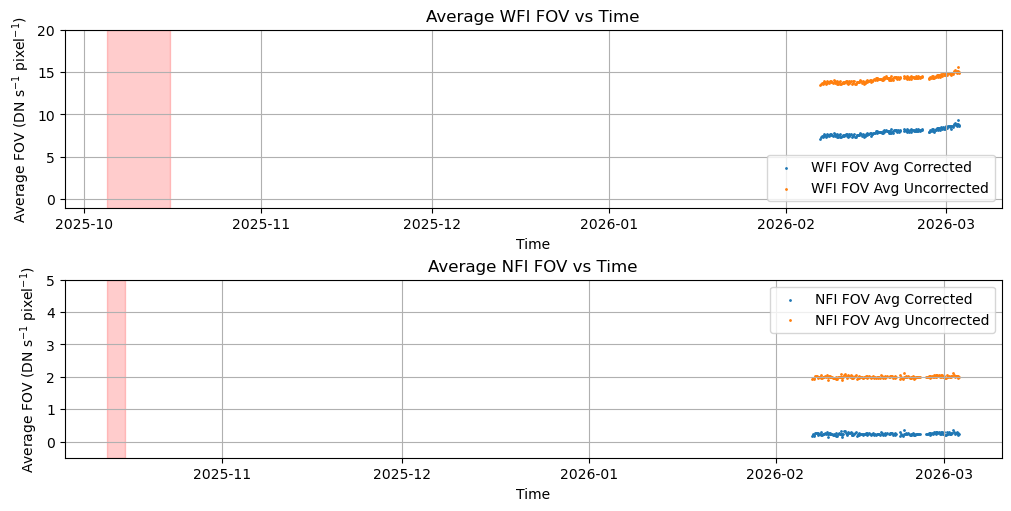

In [460]:
# COLUMN BIAS PLOT
fig, axs = plt.subplots(2, 1, figsize=(10, 5), constrained_layout=True)

lwidth = 1



plt.subplot(2, 1, 1)
plt.scatter(wfi_time, wfi_avg_fov_mean, label='WFI FOV Avg Corrected', s=1)
plt.scatter(wfi_time, wfi_avg_fov_mean_uncorrected, label='WFI FOV Avg Uncorrected', s=1)
plt.title('Average WFI FOV vs Time')
plt.xlabel('Time')
plt.ylabel('Average FOV (DN s$^{-1}$ pixel$^{-1}$)')
#plt.yscale('log')
plt.ylim(-1, 20)
plt.legend()
plt.grid(True)

wfi_s = np.datetime64("2025-10-05T00:00:00")
wfi_e = np.datetime64("2025-10-16T00:00:00")

plt.axvspan(wfi_s, wfi_e, color='red', alpha=0.2)


plt.subplot(2, 1, 2)
plt.scatter(nfi_time, nfi_avg_fov_mean, label='NFI FOV Avg Corrected', s=1)
plt.scatter(nfi_time, nfi_avg_fov_mean_uncorrected, label='NFI FOV Avg Uncorrected', s=1)

plt.title('Average NFI FOV vs Time')
plt.xlabel('Time')
plt.ylabel('Average FOV (DN s$^{-1}$ pixel$^{-1}$)')
plt.ylim(-0.5, 5)
#plt.yscale('log')
plt.legend()
plt.grid(True)


nfi_s = np.datetime64("2025-10-13T00:00:00")
nfi_e = np.datetime64("2025-10-16T00:00:00")

plt.axvspan(nfi_s, nfi_e, color='red', alpha=0.2)

plt.show()


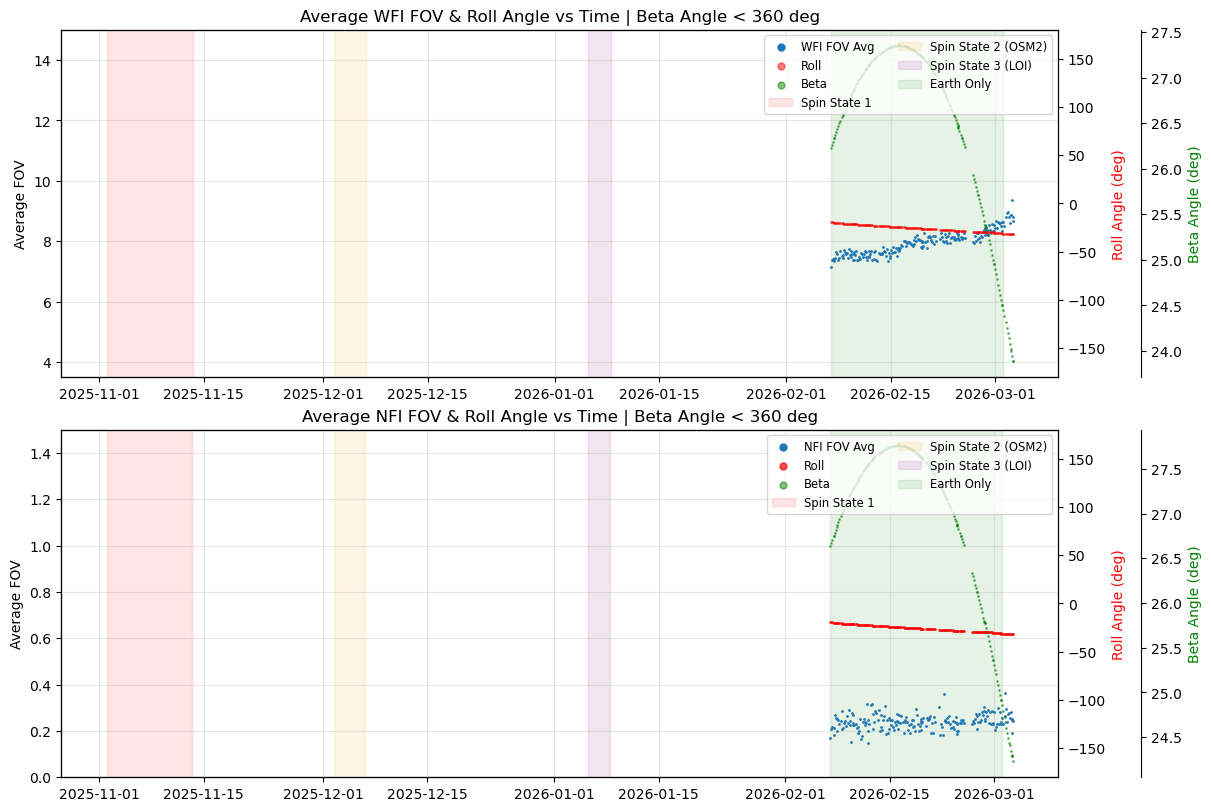

In [461]:
# DEMO THREE SPIN STATES PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

span_on = True 
plot_beta = True  # FLAG: Set to True to show Beta angle

# Spin State 1
s1 = np.datetime64("2025-11-02T00:00:00")
e1 = np.datetime64("2025-11-13T12:00:00") # modified
# Spin State 2 (OSM2)
s2 = np.datetime64("2025-12-02T12:00:00") # modfiied
e2 = np.datetime64("2025-12-06T16:00:00") # modified
# Spin State 3 (LOI)
s3 = np.datetime64("2026-01-05T12:00:00")
e3 = np.datetime64("2026-01-08T12:00:00") # modified
# Earth Only
s4 = np.datetime64("2026-02-07T00:00:00")
e4 = np.datetime64("2026-03-02T00:00:00")


# Define common span parameters
# Convert your datetime64 objects to matplotlib numbers
spans = [
    (mdates.date2num(s1), mdates.date2num(e1), 'red', 'Spin State 1'),
    (mdates.date2num(s2), mdates.date2num(e2), 'orange', 'Spin State 2 (OSM2)'),
    (mdates.date2num(s3), mdates.date2num(e3), 'purple', 'Spin State 3 (LOI)') 
    ,(mdates.date2num(s4), mdates.date2num(e4), 'green', 'Earth Only')
]


# --- Subplot 1: WFI ---
ax1.grid(True, alpha=0.3)
p1 = ax1.scatter(wfi_time, wfi_avg_fov_mean, label='WFI FOV Avg', s=1, color='tab:blue', zorder=3)
ax1.set_title(f'Average WFI FOV & Roll Angle vs Time | Beta Angle < {beta_max} deg')
ax1.set_ylabel('Average FOV')
ax1.set_ylim(3.5, 15)

# Roll Axis
ax1a = ax1.twinx()
p2 = ax1a.scatter(wfi_time, wfi_roll_angles, label='Roll', s=1, alpha=0.5, color='red', zorder=2)
ax1a.set_ylim(-180, 180)
ax1a.set_ylabel('Roll Angle (deg)', color='red')

# Beta Axis (Conditional)
handles1 = [p1, p2]
if plot_beta:
    ax1b = ax1.twinx()
    ax1b.spines['right'].set_position(('outward', 60))
    p3 = ax1b.scatter(wfi_time, wfi_beta_angles, label='Beta', s=1, alpha=0.5, color='green', zorder=2)
    ax1b.set_ylabel('Beta Angle (deg)', color='green')
    handles1.append(p3)
    top_ax1 = ax1b
else:
    top_ax1 = ax1a

# Add Spans and capture handles for legend
if span_on:
    for s, e, color, label in spans:
        span_patch = ax1.axvspan(s, e, color=color, alpha=0.1, zorder=1, label=label)
        handles1.append(span_patch) # Add the span to the legend list

top_ax1.legend(handles=handles1, loc='upper right', markerscale=5, fontsize='small', ncol=2)

# --- Subplot 2: NFI ---
ax2.grid(True, alpha=0.3)
p4 = ax2.scatter(nfi_time, nfi_avg_fov_mean, label='NFI FOV Avg', s=1, color='tab:blue', zorder=3)
ax2.set_title(f'Average NFI FOV & Roll Angle vs Time | Beta Angle < {beta_max} deg')
ax2.set_ylabel('Average FOV')
ax2.set_ylim(0, 1.5)

# Roll Axis
ax2a = ax2.twinx()
p5 = ax2a.scatter(nfi_time, nfi_roll_angles, label='Roll', s=1, alpha=0.7, color='red', zorder=2)
ax2a.set_ylim(-180, 180)
ax2a.set_ylabel('Roll Angle (deg)', color='red')

# Beta Axis (Conditional)
handles2 = [p4, p5]
if plot_beta:
    ax2b = ax2.twinx()
    ax2b.spines['right'].set_position(('outward', 60))
    p6 = ax2b.scatter(nfi_time, nfi_beta_angles, label='Beta', s=1, alpha=0.5, color='green', zorder=2)
    ax2b.set_ylabel('Beta Angle (deg)', color='green')
    handles2.append(p6)
    top_ax2 = ax2b
else:
    top_ax2 = ax2a

# Add Spans and capture handles for legend
if span_on:
    for s, e, color, label in spans:
        span_patch = ax2.axvspan(s, e, color=color, alpha=0.1, zorder=1, label=label)
        handles2.append(span_patch)

top_ax2.legend(handles=handles2, loc='upper right', markerscale=5, fontsize='small', ncol=2)

plt.show()


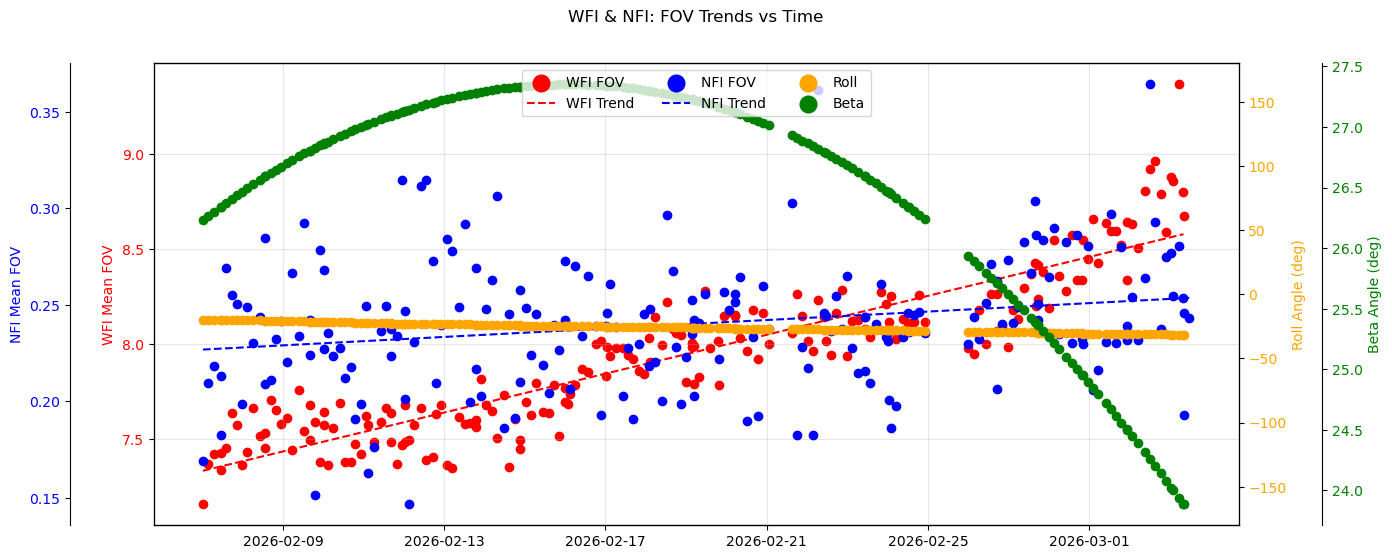

In [462]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

fig, ax1 = plt.subplots(figsize=(14, 6))

# Helper to calculate trendline
def get_trendline(x, y):
    # Convert dates to numbers for regression
    x_num = mdates.date2num(x)
    idx = np.isfinite(x_num) & np.isfinite(y) # Filter NaNs
    z = np.polyfit(x_num[idx], y[idx], 1)
    p = np.poly1d(z)
    return x, p(x_num)

# 1. Primary Axis: WFI FOV
ax1.grid(True, alpha=0.3)
p1 = ax1.scatter(wfi_time, wfi_avg_fov_mean, color='red', label='WFI FOV')
# WFI Trendline
x_w, y_w = get_trendline(wfi_time, wfi_avg_fov_mean)
t1, = ax1.plot(x_w, y_w, color='red', linestyle='--', linewidth=1.5, label='WFI Trend')
ax1.set_ylabel('WFI Mean FOV', color='red')
ax1.tick_params(axis='y', labelcolor='red')


# 2. Twin Left Axis: NFI FOV
ax0 = ax1.twinx()
ax0.yaxis.set_label_position('left')
ax0.yaxis.set_ticks_position('left')
ax0.spines['left'].set_position(('outward', 60))
p0 = ax0.scatter(nfi_time, nfi_avg_fov_mean, color='blue', alpha=1, label='NFI FOV')
# NFI Trendline
x_n, y_n = get_trendline(nfi_time, nfi_avg_fov_mean)
t0, = ax0.plot(x_n, y_n, color='blue', linestyle='--', linewidth=1.5, label='NFI Trend')
ax0.set_ylabel('NFI Mean FOV', color='blue')
ax0.tick_params(axis='y', labelcolor='blue')

# 3. Second Axis: Roll Angle (Right)
ax2 = ax1.twinx()
p2 = ax2.scatter(wfi_time, wfi_roll_angles, color='orange', alpha=1, label='Roll')
ax2.set_ylabel('Roll Angle (deg)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_ylim(-180, 180)

# 4. Third Axis: Beta Angle (Right Offset)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
p3 = ax3.scatter(wfi_time, wfi_beta_angles, color='green', alpha=1, label='Beta')
ax3.set_ylabel('Beta Angle (deg)', color='green')
ax3.tick_params(axis='y', labelcolor='green')

# Combined Legend
handles = [p1, t1, p0, t0, p2, p3]
labels = [h.get_label() for h in handles]
ax3.legend(handles, labels, loc='upper center', 
           ncol=3, markerscale=2)

plt.title('WFI & NFI: FOV Trends vs Time', pad=30)
plt.show()


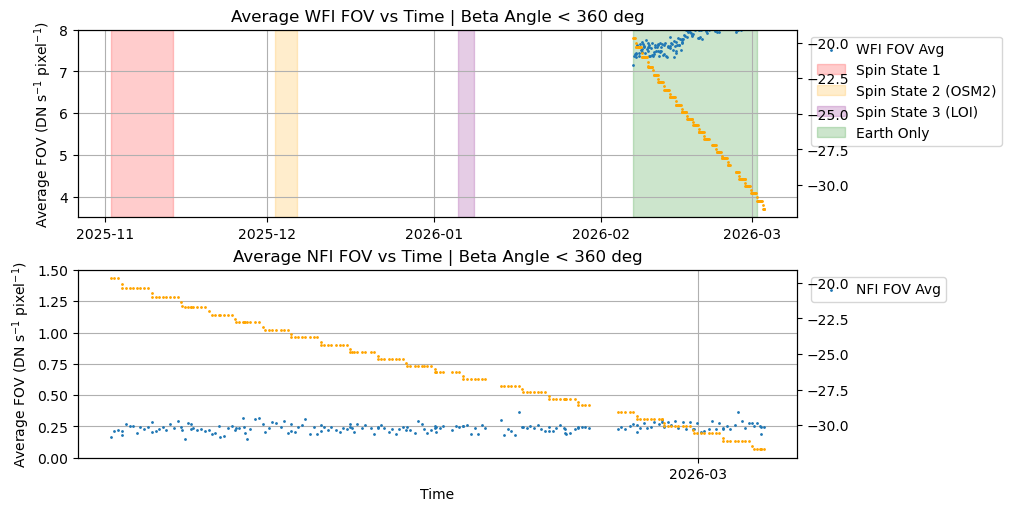

In [463]:
# PLOT FOCUS ON WFI AND ROLL / BETA

# 1. Create figure and axes objects (fixed unpacking names)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), constrained_layout=True)

# --- Subplot 1: WFI ---
ax1.scatter(wfi_time, wfi_avg_fov_mean, label='WFI FOV Avg', s=1, zorder=2)
ax1a = ax1.twinx()  # Create a twin y-axis for the roll angles
ax1a.scatter(wfi_time, wfi_roll_angles, label='WFI Roll Angles', s=1, color='orange', zorder=1)
ax1.set_title(f'Average WFI FOV vs Time | Beta Angle < {beta_max} deg')
ax1.set_ylabel('Average FOV (DN s$^{-1}$ pixel$^{-1}$)')
ax1.set_ylim(3.5, 8)
ax1.grid(True)
ax1.xaxis.set_major_locator(mdates.MonthLocator())


for s, e, color, label in spans:
    ax1.axvspan(s, e, color=color, alpha=0.2, label=label)

ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Subplot 2: NFI ---
ax2.scatter(nfi_time, nfi_avg_fov_mean, label='NFI FOV Avg', s=1, zorder=2)
ax2a = ax2.twinx()  # Create a twin y-axis for the roll angles
ax2a.scatter(nfi_time, nfi_roll_angles, label='NFI Roll Angles', s=1, color='orange', zorder=1)
ax2.set_title(f'Average NFI FOV vs Time | Beta Angle < {beta_max} deg')
ax2.set_xlabel('Time')
ax2.set_ylabel('Average FOV (DN s$^{-1}$ pixel$^{-1}$)')
ax2.set_ylim(-0, 1.5)
ax2.grid(True)
ax2.xaxis.set_major_locator(mdates.MonthLocator())

ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.show()